## Imports

In [1]:
import pandas as pd
from scipy.io import wavfile
import seaborn as sns
import matplotlib.pyplot as plt
import parselmouth
import numpy as np
import os

## Reading the Data

In [2]:
# Create DataFrame with index `File_Name`
df = pd.read_csv('audio.csv')
df.set_index('File_Name', inplace=True)

In [7]:
# Show current DF
df.head()

,Actor,Gender,Emotion,Intensity,Statement,Repetition,length
File_Name,,,,,,,
03-01-01-01-01-01-01.wav,1,M,neutral,normal,1,1,3.303292
03-01-01-01-01-02-01.wav,1,M,neutral,normal,1,2,3.336667
03-01-01-01-02-01-01.wav,1,M,neutral,normal,2,1,3.269917
03-01-01-01-02-02-01.wav,1,M,neutral,normal,2,2,3.169833
03-01-02-01-01-01-01.wav,1,M,calm,normal,1,1,3.536854


In [4]:
# Read WAV files into the DataFrame
for f in df.index:
    rate, signal = wavfile.read('data/'+f)
    # Measure length of each audio file
    df.at[f, 'length'] = signal.shape[0]/rate

C:\Users\barry\AppData\Local\Temp\ipykernel_30792\3127963651.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wavfile.read('data/'+f)
C:\Users\barry\AppData\Local\Temp\ipykernel_30792\3127963651.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wavfile.read('data/'+f)


In [5]:
# Print all unique emotions in the dataset
print(df['Emotion'].unique())
print(df['Emotion'].value_counts())

['neutral' 'calm' 'happy' 'sad' 'angry' 'fearful' 'disgust' 'surprised']
Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


## Data Cleaning

In [ ]:
# Do we need to remove (unvoiced/silent) parts in each audio file

## EDA

In [ ]:
# Distribution of emotions in the dataset ✅
# What is the duration of the audio files 
# What are the key features extracted from the audio files? 
# How do the features vary across different emotions? 
# Are there any correlations between different features? 
# How do the feature distributions look? 
# What are the summary statistics for the features?** 
#    - Mean, median, standard deviation, etc., for each feature. 

# Are there any outliers in the data?** 
#    - How will you handle outliers in the feature set? 


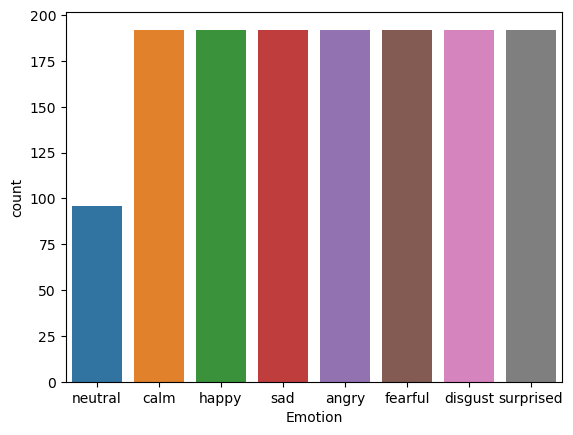

In [6]:
# Distribution of emotions in the dataset
sns.countplot(x='Emotion', data=df)
plt.show()

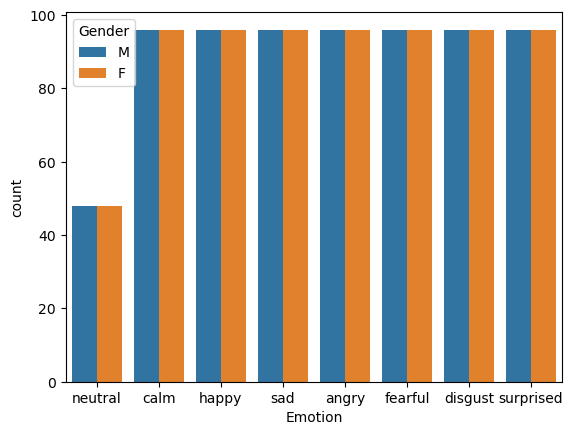

In [12]:
sns.countplot(x='Emotion', hue='Gender', data=df)
plt.show()

## Model Preparation

## Extra

In [13]:
emotion_counts = df['Emotion'].value_counts()

<Axes: xlabel='Emotion', ylabel='Count'>

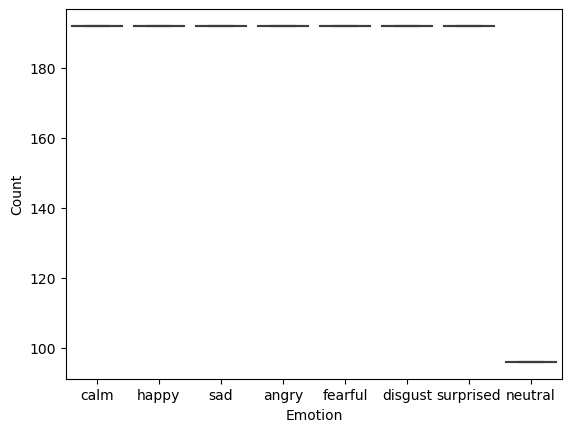

In [19]:
# Create a DataFrame with the counts of each emotion
emotion_counts = df['Emotion'].value_counts().reset_index()
emotion_counts.columns = ['Emotion', 'Count']

# # Plot using stripplot
# sns.stripplot(x='Emotion', y='Count', data=emotion_counts, jitter=True, dodge=True)
# plt.title('Emotion Counts')
# plt.show()

sns.boxplot(x ='Emotion', y ='Count', data = emotion_counts)